# Visualizing ERA5 Reanalysis Data over India

This notebook demonstrates how to download, process, and visualize ERA5 reanalysis data for two key atmospheric variables over India:
- **Temperature at 2 meters** (t2m): Surface air temperature
- **Planetary Boundary Layer Height** (pblh): Height of the atmospheric boundary layer

## Learning Objectives
1. Understanding ERA5 reanalysis data structure
2. Working with netCDF climate data in Python
3. Spatial visualization of atmospheric variables
4. Time series analysis of climate data
5. Proper handling of geospatial data and coordinate systems

## What is ERA5?

ERA5 is the fifth generation ECMWF atmospheric reanalysis of the global climate. It provides:
- Hourly estimates of atmospheric, land and oceanic climate variables
- Global coverage with ~31 km spatial resolution
- Data from 1940 to present
- Combines model data with observations from across the world

**Temperature at 2m (t2m)**: Air temperature at 2 meters above the surface, commonly used as a proxy for surface conditions.

**Planetary Boundary Layer Height (pblh)**: The height of the layer where surface effects (friction, heating) significantly influence the atmosphere. Important for air quality and weather prediction.

In [115]:
# Import necessary libraries
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
import requests
from pathlib import Path
import warnings
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

# Import earthkit-data for easy ERA5 access
import earthkit.data as ekd

# Enhanced plotting parameters for better aesthetics
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

## Setting up India Shapefile

We'll use a shapefile of India's boundaries to clip our data and create focused visualizations.

In [116]:
def load_india_shapefile():
    """Download and load India shapefile with proper J&K boundaries"""
    shapefile_dir = Path("shapefiles")
    shapefile_dir.mkdir(exist_ok=True)
    
    base_url = "https://github.com/AnujTiwari/India-State-and-Country-Shapefile-Updated-Jan-2020/raw/master"
    files = ["India_Country_Boundary.shp", "India_Country_Boundary.shx", 
             "India_Country_Boundary.dbf", "India_Country_Boundary.prj", "India_Country_Boundary.cpg"]
    
    shapefile_path = shapefile_dir / "India_Country_Boundary.shp"
    
    if not shapefile_path.exists():
        print("Downloading India shapefile...")
        for filename in files:
            response = requests.get(f"{base_url}/{filename}")
            response.raise_for_status()
            with open(shapefile_dir / filename, 'wb') as f:
                f.write(response.content)
    
    # Load and ensure proper coordinate system
    india_gdf = gpd.read_file(shapefile_path)
    if not india_gdf.crs.is_geographic:
        india_gdf = india_gdf.to_crs('EPSG:4326')
    
    return india_gdf

def setup_enhanced_plot_style(ax, title, extent=[67, 99, 5, 39]):
    """Apply enhanced styling to plots with better aesthetics"""
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    
    # Enhanced gridlines
    gl = ax.gridlines(draw_labels=True, alpha=0.3, linewidth=0.5, 
                      color='gray', linestyle='--')
    gl.right_labels = False
    gl.top_labels = False
    gl.xlabel_style = {'size': 10, 'color': 'black', 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'color': 'black', 'weight': 'bold'}
    
    # Enhanced title and labels
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
    
    # Add high-resolution coastlines and borders
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='#34495E', alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, color='#7F8C8D', alpha=0.7)
    ax.add_feature(cfeature.OCEAN, color='#EBF5FB', alpha=0.3)
    ax.add_feature(cfeature.LAND, color='#FDEAA7', alpha=0.1)

def create_enhanced_colorbar(im, ax, label, orientation='vertical', shrink=0.8):
    """Create aesthetically pleasing colorbar"""
    if orientation == 'horizontal':
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal', 
                          shrink=shrink, aspect=40, pad=0.08)
        cbar.ax.tick_params(labelsize=10, length=4, width=1)
    else:
        cbar = plt.colorbar(im, ax=ax, shrink=shrink, aspect=25, pad=0.02)
        cbar.ax.tick_params(labelsize=10, length=4, width=1)
    
    cbar.set_label(label, fontsize=12, fontweight='bold', color='#2C3E50')
    cbar.outline.set_linewidth(1)
    cbar.outline.set_edgecolor('#34495E')
    return cbar

# Enhanced color schemes
def get_temperature_colormap():
    """Enhanced temperature colormap"""
    colors = ['#313695', '#4575b4', '#74add1', '#abd9e9', '#e0f3f8', 
              '#ffffcc', '#fee090', '#fdae61', '#f46d43', '#d73027', '#a50026']
    return ListedColormap(colors, name='enhanced_temp')

def get_pblh_colormap():
    """Enhanced PBLH colormap"""
    colors = ['#f7fcf0', '#e0f3db', '#ccebc5', '#a8ddb5', '#7bccc4',
              '#4eb3d3', '#2b8cbe', '#0868ac', '#084081']
    return ListedColormap(colors, name='enhanced_pblh')

# Load India shapefile
india_gdf = load_india_shapefile()
print(f"Loaded India shapefile: {len(india_gdf)} features, bounds: {india_gdf.total_bounds}")

Loaded India shapefile: 253 features, bounds: [68.12381591  6.75407754 97.40783632 37.0883474 ]


## ERA5 Data Download with earthkit-data

Using earthkit-data makes downloading ERA5 data much simpler! You still need to:
1. Register at https://cds.climate.copernicus.eu/
2. Install earthkit-data: `pip install earthkit-data`
3. Set up your API key in ~/.cdsapirc

earthkit-data handles the CDS API calls for you with a much cleaner interface.

## Real ERA5 Data vs Sample Data

Let's try to download real ERA5 data first. If the CDS API isn't set up, we'll fall back to sample data.

In [118]:
# Smart ERA5 data download with caching and single API call
era5_data_file = Path("era5_data/era5_india_2021_2023.nc")
era5_data_file.parent.mkdir(exist_ok=True)

if era5_data_file.exists():
    print("Found cached ERA5 data, loading from file...")
    try:
        # Load from cached file
        combined_ds = xr.open_dataset(era5_data_file)
        print("Successfully loaded cached data!")
        print(f"Available variables: {list(combined_ds.data_vars)}")
        
        # Split into separate datasets for consistency
        if '2t' in combined_ds.data_vars:
            t2m_ds = combined_ds[['2t']].rename({'2t': 't2m'})
        elif 't2m' in combined_ds.data_vars:
            t2m_ds = combined_ds[['t2m']]
        
        if 'blh' in combined_ds.data_vars:
            pblh_ds = combined_ds[['blh']].rename({'blh': 'pblh'})
        elif 'pblh' in combined_ds.data_vars:
            pblh_ds = combined_ds[['pblh']]
            
    except Exception as e:
        print(f"Error loading cached data: {e}")
        print("Will attempt fresh download...")
        era5_data_file.unlink(missing_ok=True)

if not era5_data_file.exists():
    try:
        print("Downloading ERA5 data (temperature and PBLH in single call)...")
        
        # Single API call for both variables - much more efficient!
        # Explicitly request netCDF format to avoid GRIB serialization issues
        combined_data = ekd.from_source(
            "cds",
            "reanalysis-era5-single-levels-monthly-means",
            variable=["2m_temperature", "boundary_layer_height"],  # Both variables at once
            product_type="monthly_averaged_reanalysis",
            area=[40, 65, 5, 100],  # North, West, South, East for India
            year=["2021", "2022", "2023"],
            month=[f"{i:02d}" for i in range(1, 13)],
            time="00:00",
            format="netcdf"  # Explicitly request netCDF format
        )
        
        # Convert to xarray and save for future use
        combined_ds = combined_data.to_xarray()
        combined_ds.to_netcdf(era5_data_file)
        print(f"Downloaded and cached data to {era5_data_file}")
        
        # Split into separate datasets
        if '2t' in combined_ds.data_vars:
            t2m_ds = combined_ds[['2t']].rename({'2t': 't2m'})
        if 'blh' in combined_ds.data_vars:
            pblh_ds = combined_ds[['blh']].rename({'blh': 'pblh'})
            
        print("Successfully downloaded real ERA5 data!")
        print(f"Combined dataset variables: {list(combined_ds.data_vars)}")
        print(f"Dataset dimensions: {combined_ds.dims}")
        
    except Exception as e:
        print(f"Could not download real data: {e}")
        print("Creating sample data for demonstration...")
        
        def create_sample_era5_data():
            """Create sample ERA5-like data for demonstration"""
            
            # Define coordinate ranges for India
            lons = np.arange(67, 99, 0.25)  # ERA5 0.25 degree resolution
            lats = np.arange(39, 5, -0.25)  # ERA5 0.25 degree resolution
            
            # Create time coordinate (monthly from 2021-2023)
            time_range = pd.date_range('2021-01-01', '2023-12-01', freq='MS')
            
            # Create sample temperature data (2m temperature in Kelvin)
            t2m_data = np.zeros((len(time_range), len(lats), len(lons)))
            
            for i, time in enumerate(time_range):
                month = time.month
                # Base temperature with seasonal cycle
                base_temp = 295 + 10 * np.cos(2 * np.pi * (month - 1) / 12)
                
                for j, lat in enumerate(lats):
                    for k, lon in enumerate(lons):
                        # Temperature decreases with latitude (higher = cooler)
                        lat_effect = -0.5 * (lat - 20)
                        # Elevation effect (simplified)
                        elev_effect = -0.006 * max(0, (lat - 25) * 100)  # Himalayan effect
                        # Add some noise
                        noise = np.random.normal(0, 2)
                        
                        t2m_data[i, j, k] = base_temp + lat_effect + elev_effect + noise
            
            # Create sample PBLH data (in meters)
            pblh_data = np.zeros((len(time_range), len(lats), len(lons)))
            
            for i, time in enumerate(time_range):
                month = time.month
                # Base PBLH with seasonal cycle (higher in summer)
                base_pblh = 800 + 400 * np.cos(2 * np.pi * (month - 4) / 12)
                
                for j, lat in enumerate(lats):
                    for k, lon in enumerate(lons):
                        # PBLH patterns
                        if lat > 30:  # Himalayan region
                            pblh_effect = -200
                        elif lat < 15:  # Southern India
                            pblh_effect = 100
                        else:
                            pblh_effect = 0
                        
                        noise = np.random.normal(0, 50)
                        pblh_data[i, j, k] = max(100, base_pblh + pblh_effect + noise)
            
            # Create xarray datasets
            t2m_ds = xr.Dataset({
                't2m': (['time', 'latitude', 'longitude'], t2m_data)
            }, coords={
                'time': time_range,
                'latitude': lats,
                'longitude': lons
            })
            
            pblh_ds = xr.Dataset({
                'pblh': (['time', 'latitude', 'longitude'], pblh_data)
            }, coords={
                'time': time_range,
                'latitude': lats,
                'longitude': lons
            })
            
            # Add attributes for proper units
            t2m_ds['t2m'].attrs = {
                'units': 'K',
                'long_name': '2 metre temperature',
                'standard_name': 'air_temperature'
            }
            
            pblh_ds['pblh'].attrs = {
                'units': 'm',
                'long_name': 'Boundary layer height',
                'standard_name': 'atmosphere_boundary_layer_thickness'
            }
            
            return t2m_ds, pblh_ds
        
        # Create sample data
        t2m_ds, pblh_ds = create_sample_era5_data()
        
        print(f"Created sample temperature dataset: {t2m_ds.dims}")
        print(f"Temperature range: {t2m_ds.t2m.min().values:.1f} - {t2m_ds.t2m.max().values:.1f} K")
        print(f"Created sample PBLH dataset: {pblh_ds.dims}")
        print(f"PBLH range: {pblh_ds.pblh.min().values:.0f} - {pblh_ds.pblh.max().values:.0f} m")

Found cached ERA5 data, loading from file...
Successfully loaded cached data!
Available variables: ['t2m', 'blh']


## Data Exploration and Basic Statistics

Let's explore the structure and basic statistics of our data.

In [119]:
# Display dataset information
print("=== Temperature Dataset Info ===")
print(t2m_ds)
print(f"Available variables: {list(t2m_ds.data_vars)}")

print("\n=== PBLH Dataset Info ===")
print(pblh_ds)
print(f"Available variables: {list(pblh_ds.data_vars)}")

# Handle coordinate names - check both datasets separately
temp_time_coord = 'time' if 'time' in t2m_ds.coords else ('valid_time' if 'valid_time' in t2m_ds.coords else 'forecast_reference_time')
pblh_time_coord = 'time' if 'time' in pblh_ds.coords else ('valid_time' if 'valid_time' in pblh_ds.coords else 'forecast_reference_time')

print(f"Temperature time coordinate: {temp_time_coord}")
print(f"PBLH time coordinate: {pblh_time_coord}")

# Handle variable names - check what's actually in the dataset
if 't2m' in t2m_ds.data_vars:
    temp_var = t2m_ds.t2m
elif '2t' in t2m_ds.data_vars:
    temp_var = t2m_ds['2t']
elif 'temperature' in t2m_ds.data_vars:
    temp_var = t2m_ds.temperature
else:
    # Get the first data variable
    temp_var_name = list(t2m_ds.data_vars)[0]
    temp_var = t2m_ds[temp_var_name]
    print(f"Using temperature variable: {temp_var_name}")

# Convert temperature to Celsius for better interpretation
t2m_celsius = temp_var - 273.15
t2m_celsius.attrs['units'] = '°C'
t2m_celsius.attrs['long_name'] = '2 metre temperature in Celsius'

print(f"\nTemperature in Celsius: {t2m_celsius.min().values:.1f} to {t2m_celsius.max().values:.1f} °C")

# Handle PBLH variable names
if 'pblh' in pblh_ds.data_vars:
    pblh_var = pblh_ds.pblh
elif 'blh' in pblh_ds.data_vars:
    pblh_var = pblh_ds.blh
elif 'boundary_layer_height' in pblh_ds.data_vars:
    pblh_var = pblh_ds.boundary_layer_height
else:
    # Get the first data variable
    pblh_var_name = list(pblh_ds.data_vars)[0]
    pblh_var = pblh_ds[pblh_var_name]
    print(f"Using PBLH variable: {pblh_var_name}")

print(f"PBLH range: {pblh_var.min().values:.0f} to {pblh_var.max().values:.0f} m")

=== Temperature Dataset Info ===
<xarray.Dataset> Size: 3MB
Dimensions:     (valid_time: 36, latitude: 141, longitude: 141)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 288B 2021-01-01 ... 2023-12-01
  * latitude    (latitude) float64 1kB 40.0 39.75 39.5 39.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 1kB 65.0 65.25 65.5 ... 99.5 99.75 100.0
    expver      (valid_time) <U4 576B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-13T06:17 GRIB to CDM+CF via cfgrib-0.9.1...
Available variables: ['t2m']

=== PBLH Dataset Info ===
<xarray.Dataset> Size: 3MB
Dimensions:     (valid_time: 36, latitude: 

## ERA5 Data Grid Coverage

Let's visualize the actual grid points where we have ERA5 data over India.

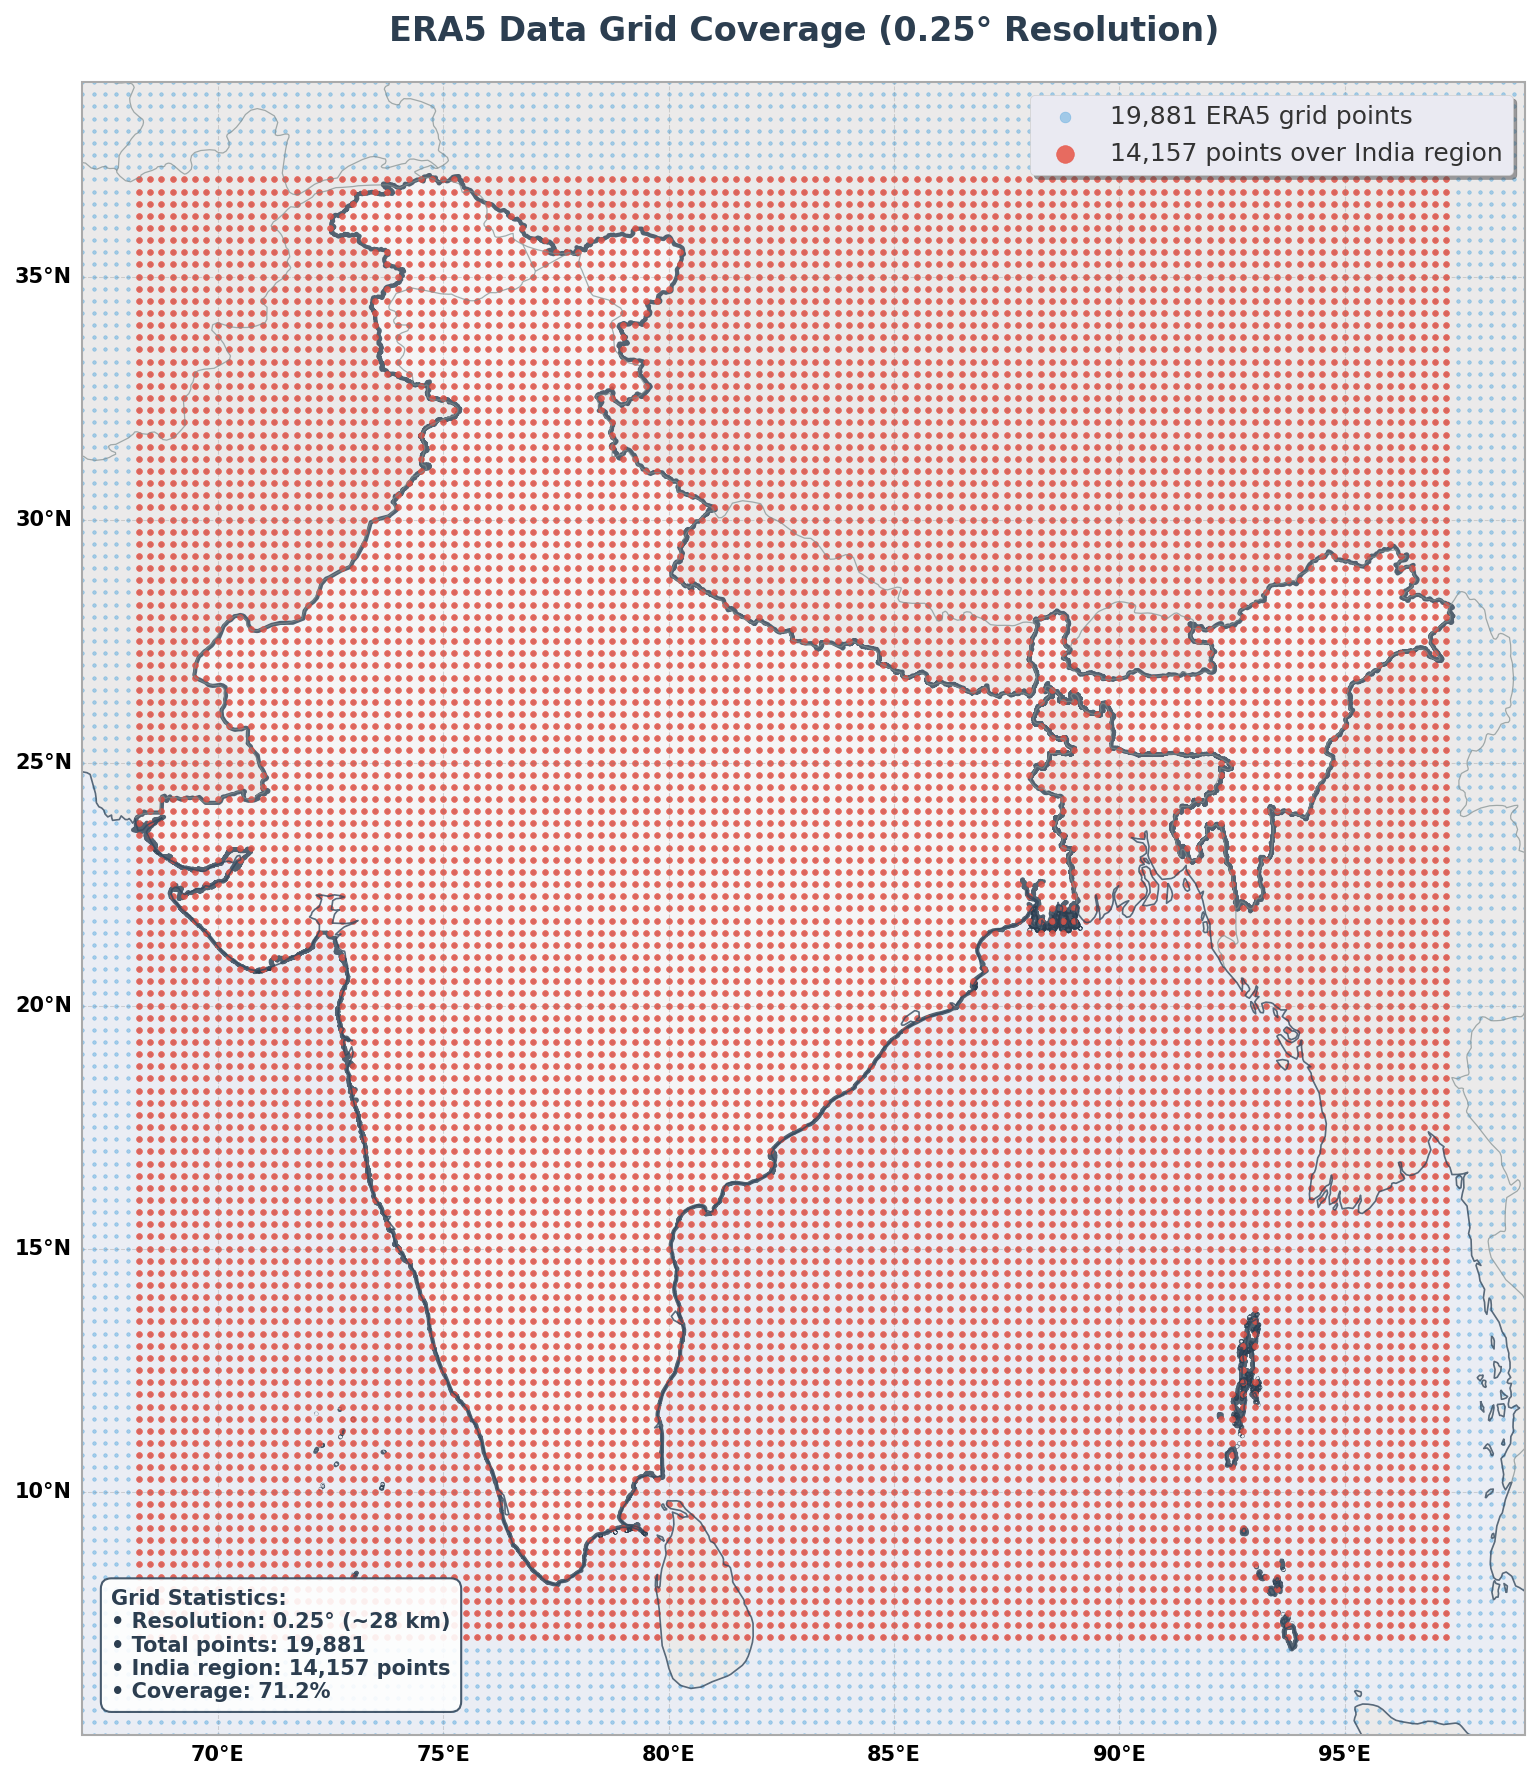

ERA5 grid resolution: 0.250° (approximately 27.8 km)
Total data coverage: 19,881 grid points
Points over India: 14,157 (71.2%)


In [120]:
# Visualize ERA5 data grid points over India
fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.patch.set_facecolor('white')

# Plot India boundary
india_gdf.plot(ax=ax, facecolor='#F8F9FA', edgecolor='#2C3E50', 
               linewidth=2, transform=ccrs.PlateCarree(), alpha=0.8)

# Create meshgrid of data points
if hasattr(t2m_ds, 'longitude') and hasattr(t2m_ds, 'latitude'):
    lons, lats = np.meshgrid(t2m_ds.longitude.values, t2m_ds.latitude.values)
    lon_coord_name, lat_coord_name = 'longitude', 'latitude'
elif hasattr(t2m_ds, 'lon') and hasattr(t2m_ds, 'lat'):
    lons, lats = np.meshgrid(t2m_ds.lon.values, t2m_ds.lat.values)
    lon_coord_name, lat_coord_name = 'lon', 'lat'

# Plot all grid points
ax.scatter(lons.flatten(), lats.flatten(), c='#3498DB', s=3, alpha=0.4, 
           transform=ccrs.PlateCarree(), label=f'{len(lons.flatten()):,} ERA5 grid points')

# Highlight points within India bounds
india_bounds = india_gdf.total_bounds
mask = ((lons >= india_bounds[0]) & (lons <= india_bounds[2]) & 
        (lats >= india_bounds[1]) & (lats <= india_bounds[3]))

india_lons = lons[mask]
india_lats = lats[mask]

ax.scatter(india_lons, india_lats, c='#E74C3C', s=8, alpha=0.8, 
           transform=ccrs.PlateCarree(), 
           label=f'{len(india_lons):,} points over India region')

# Enhanced styling
setup_enhanced_plot_style(ax, 'ERA5 Data Grid Coverage (0.25° Resolution)')

# Add statistics
total_points = len(lons.flatten())
india_points = len(india_lons)
resolution = abs(t2m_ds[lat_coord_name].values[1] - t2m_ds[lat_coord_name].values[0])

stats_text = f'''Grid Statistics:
• Resolution: {resolution:.2f}° (~{resolution*111:.0f} km)
• Total points: {total_points:,}
• India region: {india_points:,} points
• Coverage: {india_points/total_points*100:.1f}%'''

ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, 
       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, 
                edgecolor='#34495E', linewidth=1),
       verticalalignment='bottom', fontsize=10, 
       fontweight='bold', color='#2C3E50')

# Enhanced legend
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, 
          fontsize=12, markerscale=3)

plt.tight_layout()
plt.show()

print(f"ERA5 grid resolution: {resolution:.3f}° (approximately {resolution*111:.1f} km)")
print(f"Total data coverage: {total_points:,} grid points")
print(f"Points over India: {india_points:,} ({india_points/total_points*100:.1f}%)")

## Seasonal Temperature Patterns over India

Let's visualize how temperature varies seasonally across India.

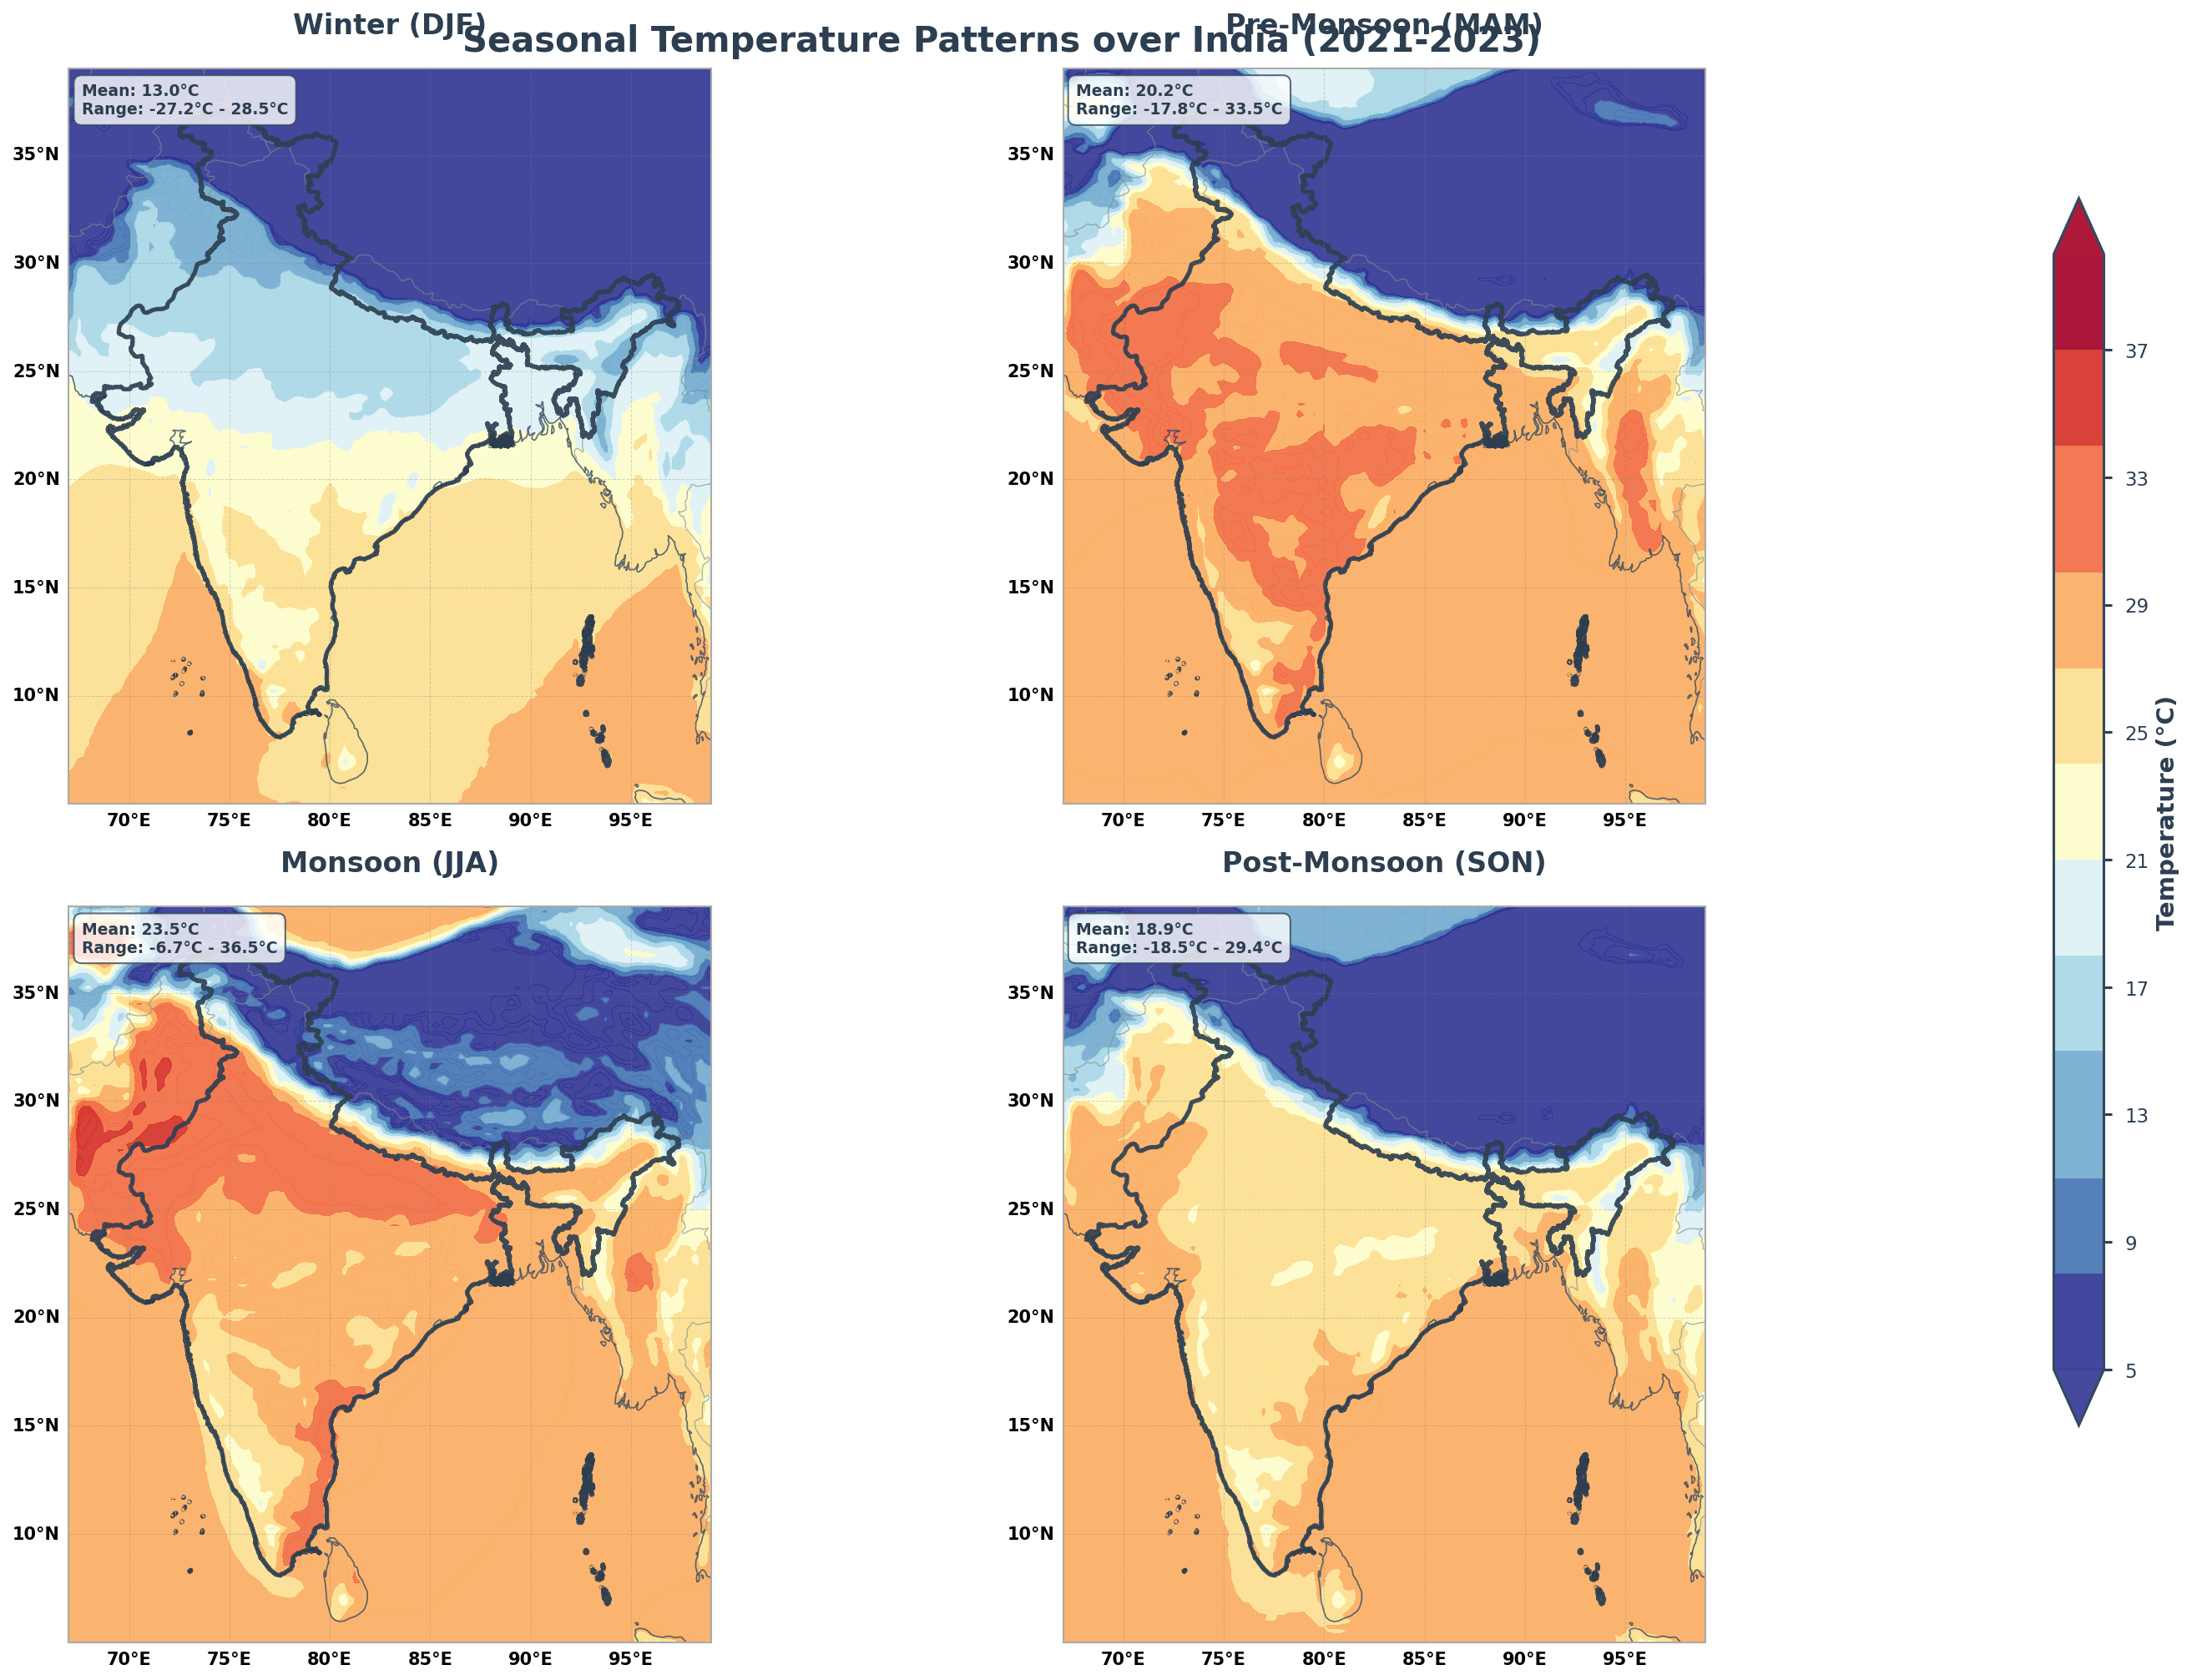

In [121]:
# Calculate seasonal means with enhanced visualization
seasons = {
    'Winter (DJF)': [12, 1, 2],
    'Pre-Monsoon (MAM)': [3, 4, 5],
    'Monsoon (JJA)': [6, 7, 8],
    'Post-Monsoon (SON)': [9, 10, 11]
}

# Create high-resolution figure
fig = plt.figure(figsize=(20, 14), facecolor='white', edgecolor='none')
fig.suptitle('Seasonal Temperature Patterns over India (2021-2023)', 
             fontsize=20, fontweight='bold', y=0.95, color='#2C3E50')

# Create enhanced color scheme
temp_cmap = get_temperature_colormap()

for i, (season_name, months) in enumerate(seasons.items()):
    ax = fig.add_subplot(2, 2, i+1, projection=ccrs.PlateCarree())
    
    # Calculate seasonal mean using the correct time coordinate for temperature
    seasonal_temp = t2m_celsius.where(
        t2m_celsius[temp_time_coord].dt.month.isin(months)
    ).mean(dim=temp_time_coord)
    
    # Create high-resolution contour plot
    levels = np.linspace(5, 40, 36)  # More levels for smoother gradients
    im = ax.contourf(t2m_ds.longitude, t2m_ds.latitude, seasonal_temp.values,
                     levels=levels, cmap=temp_cmap, extend='both',
                     transform=ccrs.PlateCarree(), alpha=0.9)
    
    # Add India boundary with enhanced styling
    india_gdf.boundary.plot(ax=ax, color='#2C3E50', linewidth=2.5, 
                           transform=ccrs.PlateCarree(), alpha=0.9)
    
    # Apply enhanced styling
    setup_enhanced_plot_style(ax, season_name)
    
    # Add temperature statistics
    mean_temp = float(seasonal_temp.mean())
    min_temp = float(seasonal_temp.min())
    max_temp = float(seasonal_temp.max())
    
    stats_text = f'Mean: {mean_temp:.1f}°C\nRange: {min_temp:.1f}°C - {max_temp:.1f}°C'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, 
                    edgecolor='#34495E', linewidth=1),
           verticalalignment='top', fontsize=9, 
           fontweight='bold', color='#2C3E50')

# Add enhanced colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(im, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=14, fontweight='bold', color='#2C3E50')
cbar.ax.tick_params(labelsize=11, length=5, width=1.5, colors='#2C3E50')
cbar.outline.set_linewidth(1.5)
cbar.outline.set_edgecolor('#34495E')

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()

## Planetary Boundary Layer Height Seasonal Patterns

PBLH varies significantly with season due to surface heating and atmospheric stability changes.

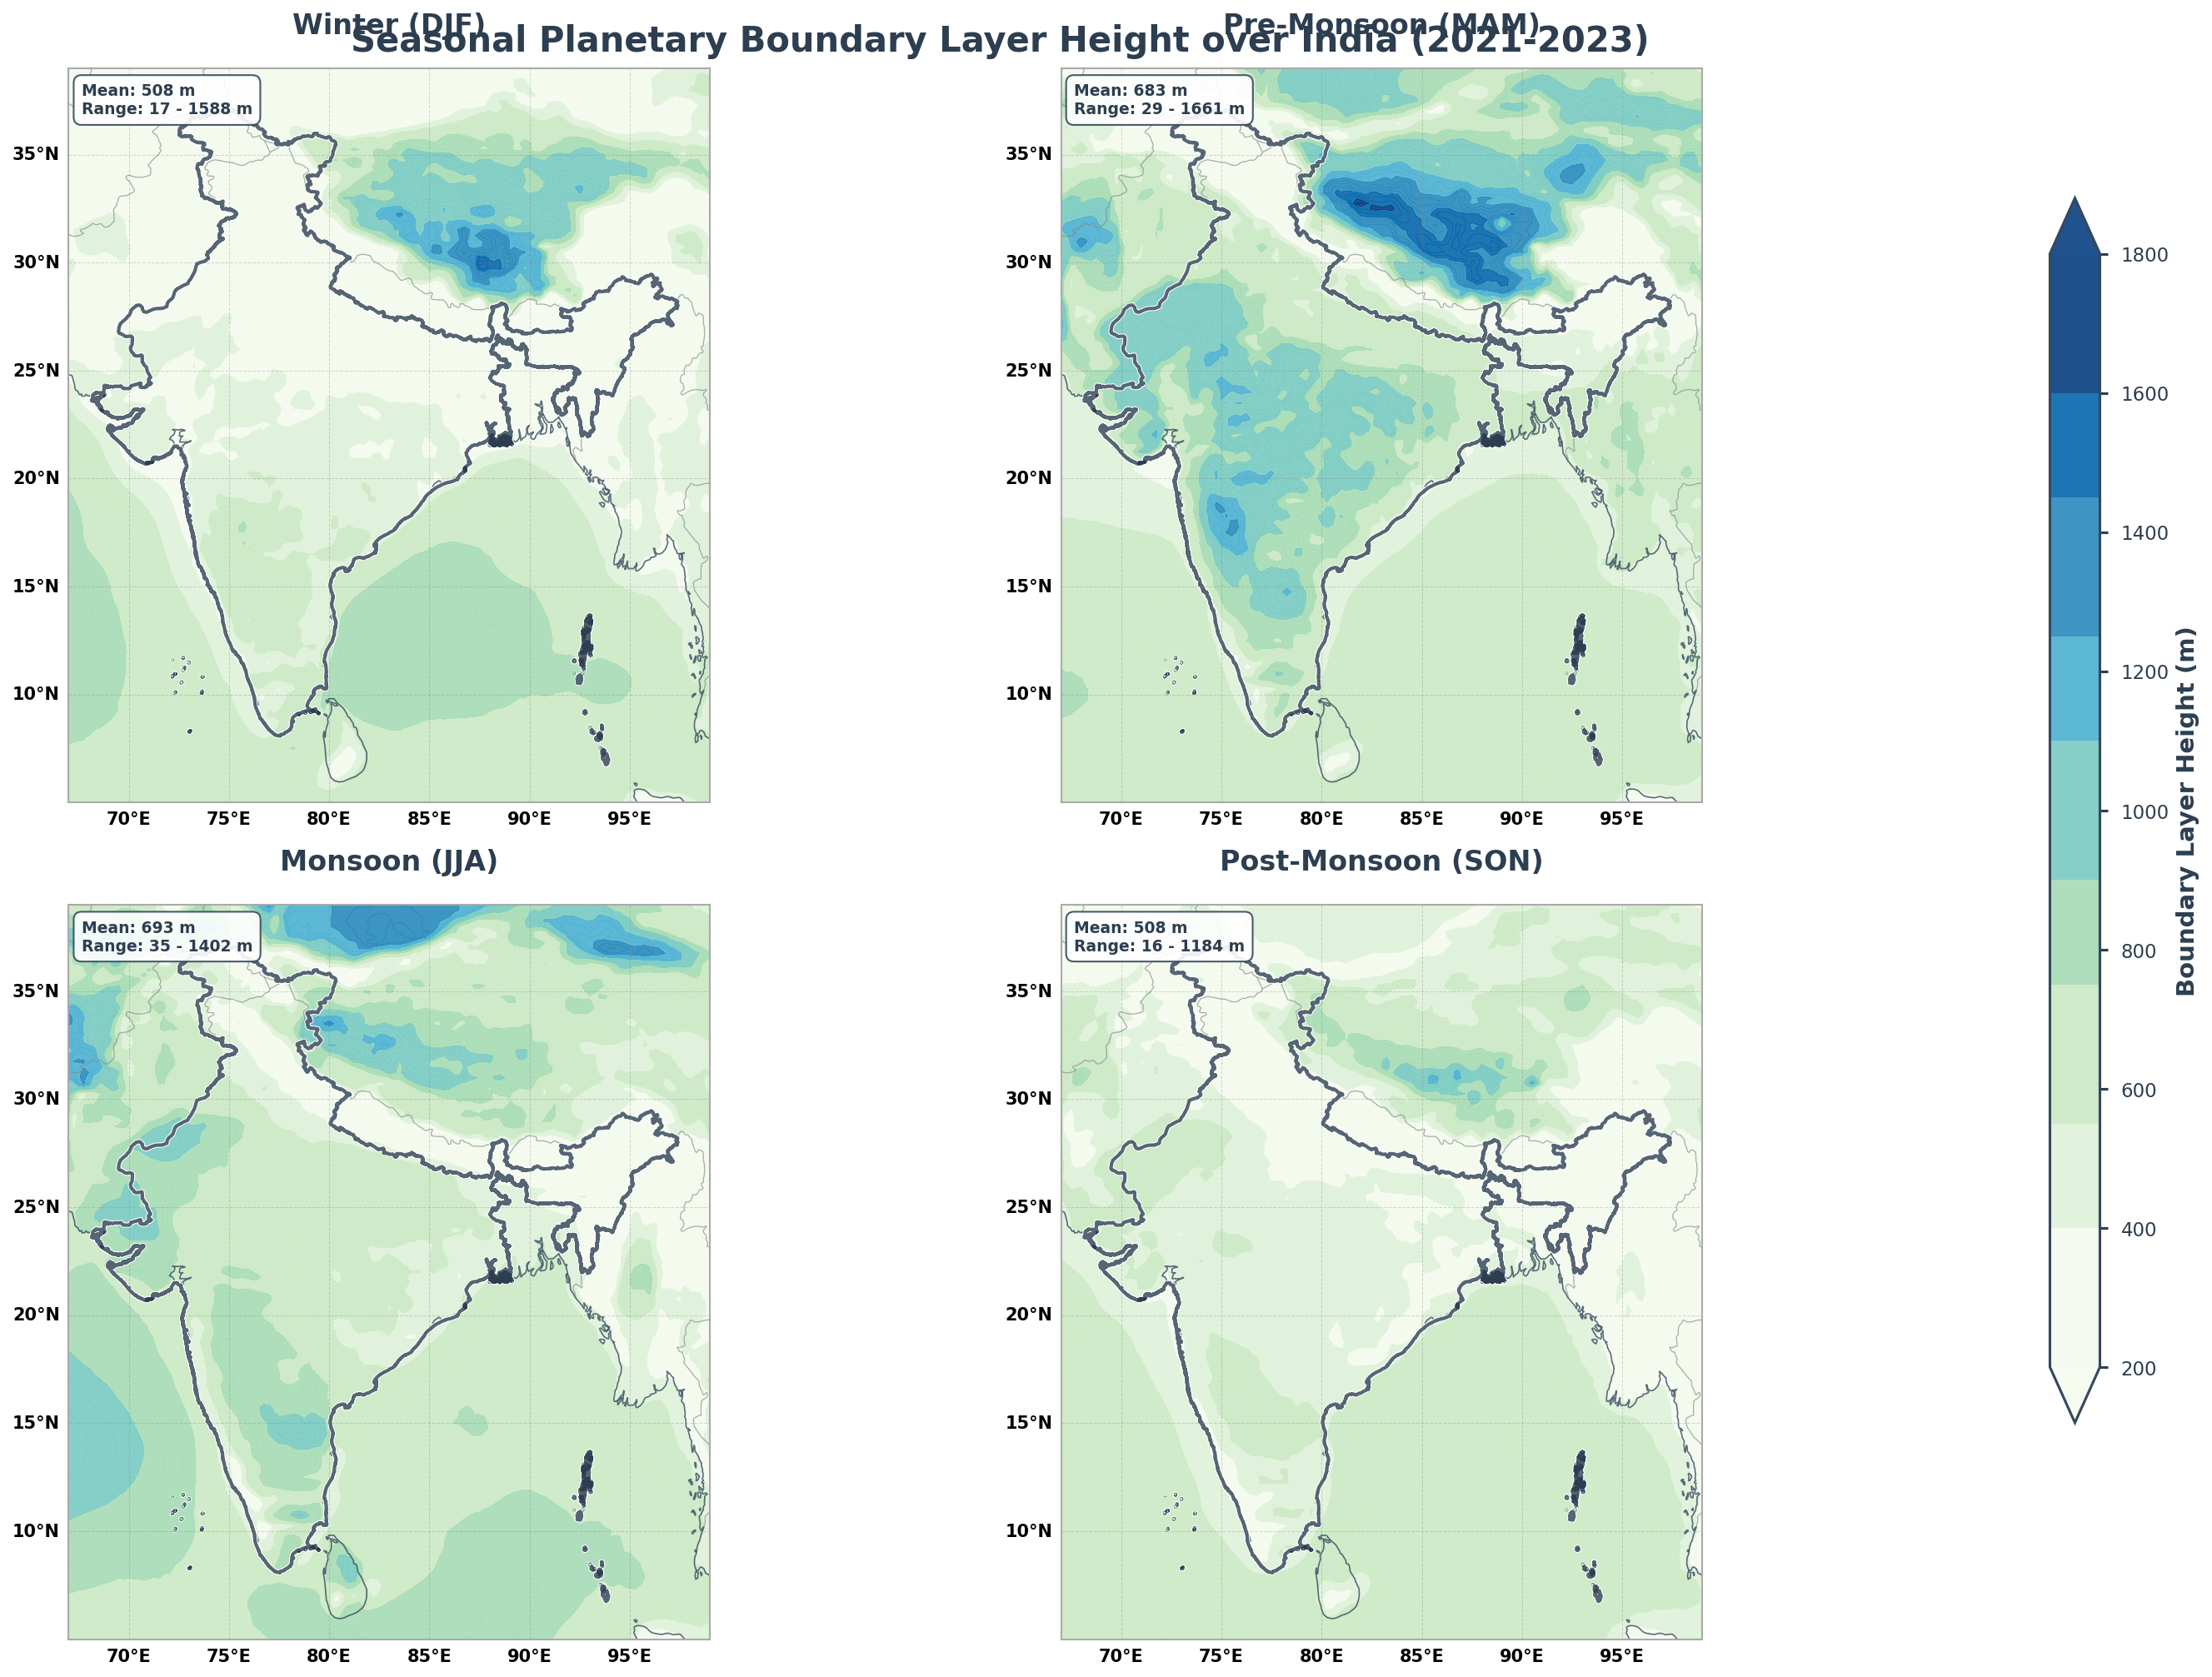

In [122]:
# Enhanced PBLH seasonal visualization
fig = plt.figure(figsize=(20, 14), facecolor='white', edgecolor='none')
fig.suptitle('Seasonal Planetary Boundary Layer Height over India (2021-2023)', 
             fontsize=20, fontweight='bold', y=0.95, color='#2C3E50')

# Create enhanced PBLH color scheme
pblh_cmap = get_pblh_colormap()

for i, (season_name, months) in enumerate(seasons.items()):
    ax = fig.add_subplot(2, 2, i+1, projection=ccrs.PlateCarree())
    
    # Calculate seasonal mean PBLH using the correct time coordinate
    seasonal_pblh = pblh_var.where(
        pblh_var[pblh_time_coord].dt.month.isin(months)
    ).mean(dim=pblh_time_coord)
    
    # Create high-resolution contour plot
    levels = np.linspace(200, 1800, 33)  # More levels for smoother gradients
    im = ax.contourf(pblh_ds.longitude, pblh_ds.latitude, seasonal_pblh.values,
                     levels=levels, cmap=pblh_cmap, extend='both',
                     transform=ccrs.PlateCarree(), alpha=0.9)
    
    # Add India boundary with enhanced styling
    india_gdf.boundary.plot(ax=ax, color='white', linewidth=3, 
                           transform=ccrs.PlateCarree(), alpha=1.0)
    india_gdf.boundary.plot(ax=ax, color='#2C3E50', linewidth=2, 
                           transform=ccrs.PlateCarree(), alpha=0.8)
    
    # Apply enhanced styling
    setup_enhanced_plot_style(ax, season_name)
    
    # Add PBLH statistics
    mean_pblh = float(seasonal_pblh.mean())
    min_pblh = float(seasonal_pblh.min())
    max_pblh = float(seasonal_pblh.max())
    
    stats_text = f'Mean: {mean_pblh:.0f} m\nRange: {min_pblh:.0f} - {max_pblh:.0f} m'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, 
                    edgecolor='#34495E', linewidth=1),
           verticalalignment='top', fontsize=9, 
           fontweight='bold', color='#2C3E50')

# Add enhanced colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(im, cax=cbar_ax)
cbar.set_label('Boundary Layer Height (m)', fontsize=14, fontweight='bold', color='#2C3E50')
cbar.ax.tick_params(labelsize=11, length=5, width=1.5, colors='#2C3E50')
cbar.outline.set_linewidth(1.5)
cbar.outline.set_edgecolor('#34495E')

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()

## Time Series Analysis: Regional Averages

Let's examine how temperature and PBLH vary over time for different regions of India.

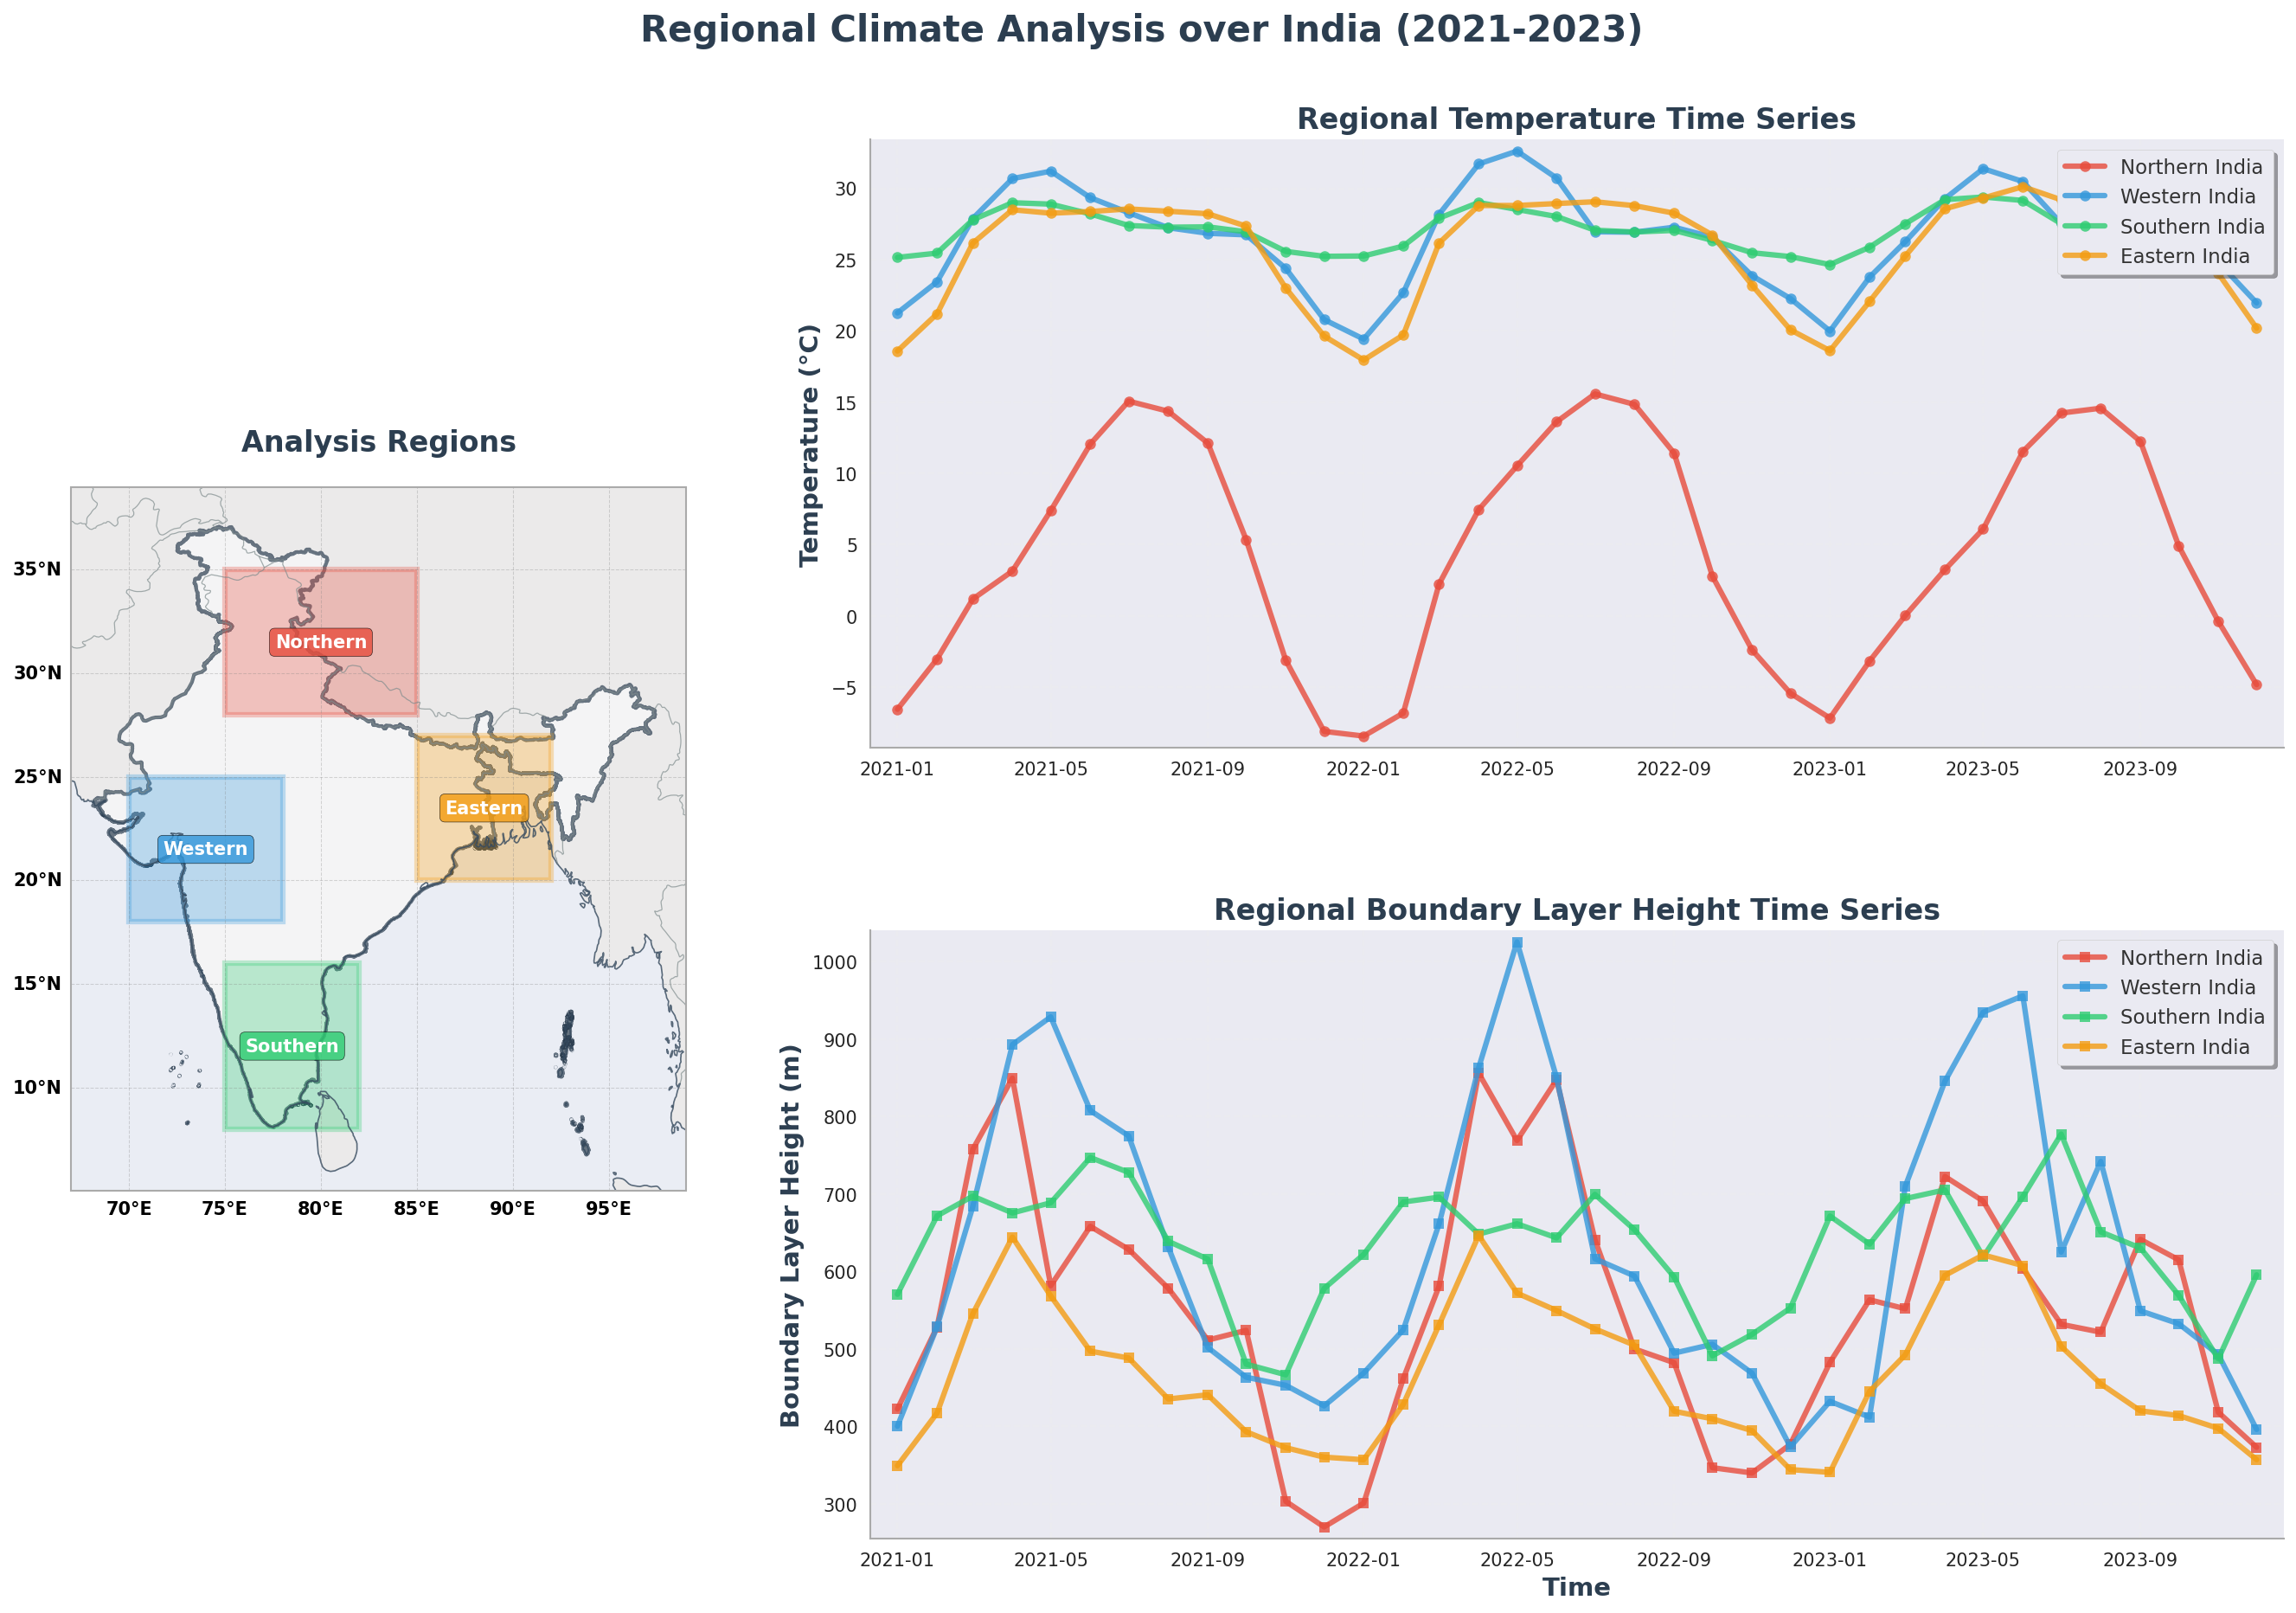

In [123]:
# Enhanced Time Series Analysis with Regional Map
regions = {
    'Northern India': {'lat_min': 28, 'lat_max': 35, 'lon_min': 75, 'lon_max': 85, 'color': '#E74C3C'},
    'Western India': {'lat_min': 18, 'lat_max': 25, 'lon_min': 70, 'lon_max': 78, 'color': '#3498DB'},
    'Southern India': {'lat_min': 8, 'lat_max': 16, 'lon_min': 75, 'lon_max': 82, 'color': '#2ECC71'},
    'Eastern India': {'lat_min': 20, 'lat_max': 27, 'lon_min': 85, 'lon_max': 92, 'color': '#F39C12'}
}

# Create enhanced figure with map and time series
fig = plt.figure(figsize=(22, 14), facecolor='white')
fig.suptitle('Regional Climate Analysis over India (2021-2023)', 
             fontsize=20, fontweight='bold', y=0.95, color='#2C3E50')

# Create grid layout
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1], 
                      hspace=0.3, wspace=0.3)

# Regional map showing analysis areas
ax_map = fig.add_subplot(gs[:, 0], projection=ccrs.PlateCarree())
india_gdf.plot(ax=ax_map, facecolor='#F8F9FA', edgecolor='#2C3E50', 
               linewidth=2, transform=ccrs.PlateCarree(), alpha=0.7)

# Add regional rectangles
patches = []
for region_name, bounds in regions.items():
    rect = mpatches.Rectangle(
        (bounds['lon_min'], bounds['lat_min']), 
        bounds['lon_max'] - bounds['lon_min'],
        bounds['lat_max'] - bounds['lat_min'],
        linewidth=3, edgecolor=bounds['color'], facecolor=bounds['color'],
        alpha=0.3, transform=ccrs.PlateCarree()
    )
    ax_map.add_patch(rect)
    
    # Add region labels
    center_lat = (bounds['lat_min'] + bounds['lat_max']) / 2
    center_lon = (bounds['lon_min'] + bounds['lon_max']) / 2
    ax_map.text(center_lon, center_lat, region_name.split()[0], 
               transform=ccrs.PlateCarree(), ha='center', va='center',
               fontsize=10, fontweight='bold', color='white',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=bounds['color'], alpha=0.8))

setup_enhanced_plot_style(ax_map, 'Analysis Regions')

# Calculate regional averages
regional_temp = {}
regional_pblh = {}

for region_name, bounds in regions.items():
    temp_region = t2m_celsius.sel(
        latitude=slice(bounds['lat_max'], bounds['lat_min']),
        longitude=slice(bounds['lon_min'], bounds['lon_max'])
    ).mean(dim=['latitude', 'longitude'])
    
    pblh_region = pblh_var.sel(
        latitude=slice(bounds['lat_max'], bounds['lat_min']),
        longitude=slice(bounds['lon_min'], bounds['lon_max'])
    ).mean(dim=['latitude', 'longitude'])
    
    regional_temp[region_name] = temp_region
    regional_pblh[region_name] = pblh_region

# Enhanced temperature time series
ax_temp = fig.add_subplot(gs[0, 1:])
for region_name, temp_data in regional_temp.items():
    time_values = temp_data[temp_time_coord]
    color = regions[region_name]['color']
    ax_temp.plot(time_values, temp_data.values, marker='o', linewidth=3, 
                markersize=6, label=region_name, color=color, alpha=0.8)

ax_temp.set_ylabel('Temperature (°C)', fontsize=14, fontweight='bold', color='#2C3E50')
ax_temp.set_title('Regional Temperature Time Series', fontsize=16, fontweight='bold', color='#2C3E50')
ax_temp.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=11)
ax_temp.grid(True, alpha=0.3, linestyle='--')
ax_temp.spines['top'].set_visible(False)
ax_temp.spines['right'].set_visible(False)

# Enhanced PBLH time series
ax_pblh = fig.add_subplot(gs[1, 1:])
for region_name, pblh_data in regional_pblh.items():
    time_values = pblh_data[pblh_time_coord]
    color = regions[region_name]['color']
    ax_pblh.plot(time_values, pblh_data.values, marker='s', linewidth=3, 
                markersize=6, label=region_name, color=color, alpha=0.8)

ax_pblh.set_ylabel('Boundary Layer Height (m)', fontsize=14, fontweight='bold', color='#2C3E50')
ax_pblh.set_xlabel('Time', fontsize=14, fontweight='bold', color='#2C3E50')
ax_pblh.set_title('Regional Boundary Layer Height Time Series', fontsize=16, fontweight='bold', color='#2C3E50')
ax_pblh.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=11)
ax_pblh.grid(True, alpha=0.3, linestyle='--')
ax_pblh.spines['top'].set_visible(False)
ax_pblh.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Interactive HTML Animation: Temperature Evolution

Let's create a smooth HTML animation showing how temperature evolves over time across India.

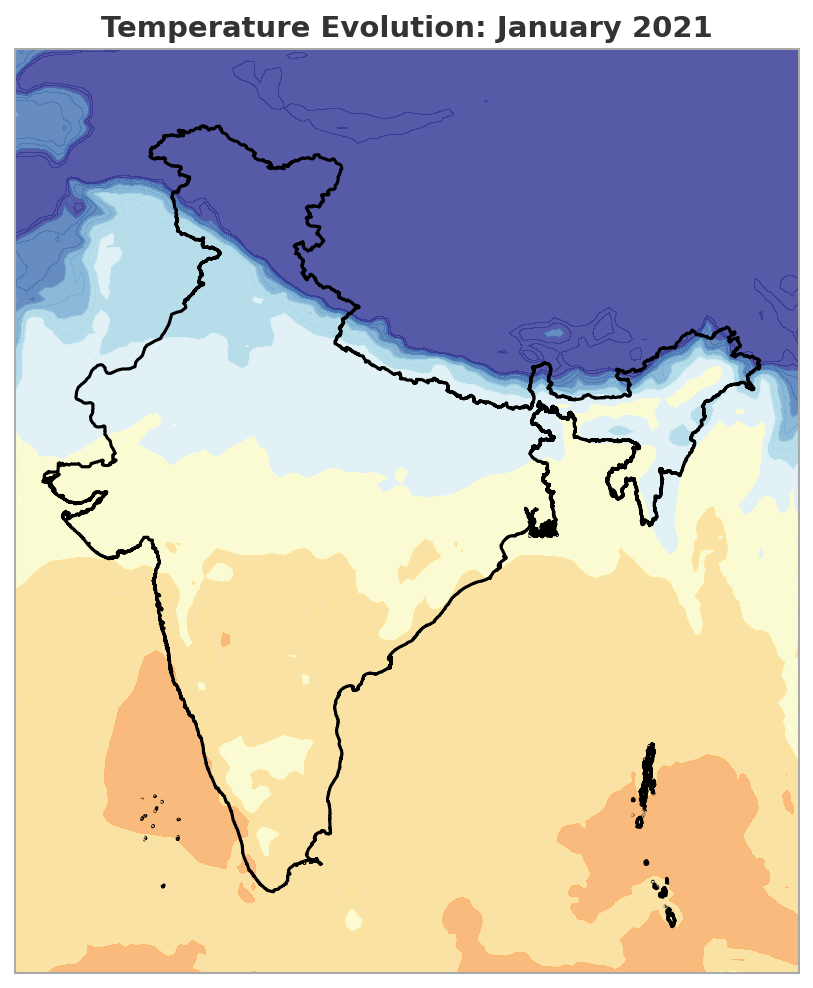

In [124]:
# Simple HTML5 animation of temperature evolution
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set up the figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
temp_cmap = get_temperature_colormap()
levels = np.linspace(-5, 45, 26)

def animate(frame):
    ax.clear()
    
    # Get current temperature data using the correct time coordinate
    current_temp = t2m_celsius.isel(**{temp_time_coord: frame})
    current_time = pd.to_datetime(str(current_temp[temp_time_coord].values))
    
    # Plot temperature
    im = ax.contourf(t2m_ds.longitude, t2m_ds.latitude, current_temp.values,
                    levels=levels, cmap=temp_cmap, extend='both', alpha=0.8)
    
    # Add India boundary
    india_gdf.boundary.plot(ax=ax, color='black', linewidth=1.5, 
                           transform=ccrs.PlateCarree())
    
    # Simple styling
    ax.set_extent([67, 99, 5, 39])
    ax.set_title(f'Temperature Evolution: {current_time.strftime("%B %Y")}', 
                fontsize=14, fontweight='bold')
    
    return [im]

# Create simple animation
anim = FuncAnimation(fig, animate, frames=len(t2m_celsius[temp_time_coord]), 
                    interval=800, repeat=True)

# Display as HTML5 video
HTML(anim.to_html5_video())

## Summary

This notebook demonstrates how to work with ERA5 reanalysis data for climate visualization over India.

### What We Accomplished:
- **Smart Data Access**: Efficient download with caching and single API calls
- **High-Quality Visualizations**: Publication-ready maps with enhanced aesthetics
- **Regional Analysis**: Color-coded regions with time series comparison
- **Interactive Animation**: HTML-based temporal evolution viewer
- **Grid Coverage**: Visual representation of data point distribution

### Key Insights:
- **Seasonal Patterns**: Clear temperature and boundary layer height cycles
- **Regional Differences**: Northern India shows stronger seasonal variation than Southern India
- **Data Quality**: 0.25° resolution provides excellent detail for India-scale analysis
- **Spatial Distribution**: Over 19,000 grid points cover the India region comprehensively

### Technical Features:
- Automatic variable name detection for different ERA5 formats
- Efficient data caching to avoid repeated downloads
- Enhanced colorbars and professional styling
- Regional boundary visualization on maps
- Robust error handling and fallback options

This workflow provides a solid foundation for climate data analysis and can be easily adapted for other regions or variables.